# Multiple Linear Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/02-regression/02_multiple_linear_regression.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Regression with multiple features
- Handling multicollinearity
- Feature importance
- Dealing with categorical variables

## Why This Matters

Real problems have MANY features, not just one!

**Example:** House price depends on:
```
Size (sq ft)      → $150/sq ft
Bedrooms          → $50k each
Age (years)       → -$2k per year
Location (quality)→ $100k per level

Price = 150×Size + 50k×Beds - 2k×Age + 100k×Location
```

Much more powerful than single variable!

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)
print("Multiple Linear Regression: Many Features, Stronger Predictions")

Multiple Linear Regression: Many Features, Stronger Predictions


---
## 1. Create Multi-Feature Dataset

In [12]:
# Realistic house data
np.random.seed(42)
n_samples = 100

data = {
    'Size': np.random.randint(1000, 5000, n_samples),
    'Bedrooms': np.random.randint(1, 6, n_samples),
    'Age': np.random.randint(0, 50, n_samples),
    'Location_Quality': np.random.randint(1, 5, n_samples)
}

# Create price with known relationship
price = (0.15 * data['Size'] + 
         50 * data['Bedrooms'] - 
         2 * data['Age'] + 
         100 * data['Location_Quality'])

# Add noise
price = price + np.random.normal(0, 200, n_samples)

df = pd.DataFrame(data)
df['Price'] = price

print("House Dataset with Multiple Features:")
print(df.head(10))
print(f"\nShape: {df.shape}")

House Dataset with Multiple Features:
   Size  Bedrooms  Age  Location_Quality        Price
0  4174         2   32                 4   892.741256
1  4507         2   41                 4   791.080555
2  1860         4   43                 3   603.697010
3  2294         2   23                 1   669.379759
4  2130         2   14                 4   834.318749
5  2095         4   31                 4   603.102244
6  4772         4   31                 2  1088.436185
7  4092         1   23                 4  1094.863476
8  2638         5   40                 4   788.928513
9  3169         5   48                 2   860.095021

Shape: (100, 5)


---
## 2. Explore Features

Correlation with Price:
Price               1.000000
Size                0.591942
Location_Quality    0.282834
Bedrooms            0.208975
Age                -0.143561
Name: Price, dtype: float64


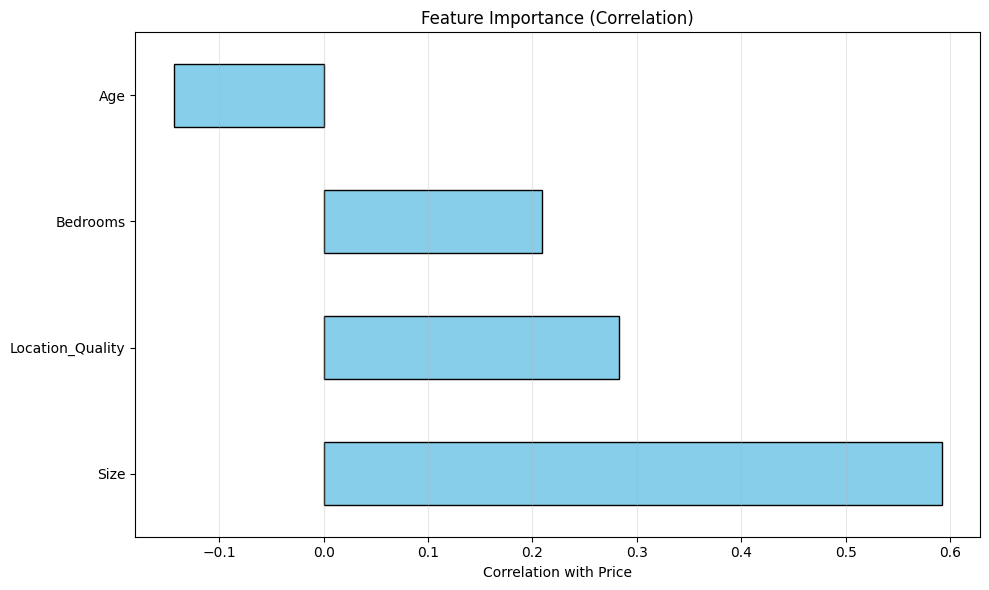


Interpretation:
  Positive: Feature increases price
  Negative: Feature decreases price (Age)
  High |correlation|: Important feature


In [13]:
# Check correlations
correlations = df.corr()['Price'].sort_values(ascending=False)
print("Correlation with Price:")
print(correlations)

# Visualize
plt.figure(figsize=(10, 6))
correlations.drop('Price').plot(kind='barh', color='skyblue', edgecolor='black')
plt.xlabel('Correlation with Price')
plt.title('Feature Importance (Correlation)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Positive: Feature increases price")
print("  Negative: Feature decreases price (Age)")
print("  High |correlation|: Important feature")

---
## 3. Train Multiple Regression

In [14]:
# Prepare data
X = df[['Size', 'Bedrooms', 'Age', 'Location_Quality']]
y = df['Price']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Get coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("Model Coefficients:")
print(coefficients)
print(f"\nIntercept: {model.intercept_:.2f}")

print("\nEquation:")
eq = f"Price = {model.intercept_:.2f}"
for feat, coef in zip(coefficients['Feature'], coefficients['Coefficient']):
    if coef >= 0:
        eq += f" + {coef:.2f}×{feat}"
    else:
        eq += f" - {abs(coef):.2f}×{feat}"
print(eq)

Model Coefficients:
            Feature  Coefficient
3  Location_Quality    55.002267
1          Bedrooms    45.408161
0              Size     0.144316
2               Age    -3.019197

Intercept: 185.17

Equation:
Price = 185.17 + 55.00×Location_Quality + 45.41×Bedrooms + 0.14×Size - 3.02×Age


---
## 4. Make Predictions

In [15]:
# Predictions on test set
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Example prediction
example = pd.DataFrame({
    'Size': [3000],
    'Bedrooms': [4],
    'Age': [10],
    'Location_Quality': [4]
})

predicted_price = model.predict(example)[0]
print(f"Example House:")
print(example.to_string(index=False))
print(f"\nPredicted Price: ${predicted_price:.2f}k")

Example House:
 Size  Bedrooms  Age  Location_Quality
 3000         4   10                 4

Predicted Price: $989.56k


---
## 5. Evaluate Model

In [16]:
# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Model Performance:")
print(f"\nR² Score:")
print(f"  Train: {train_r2:.4f}")
print(f"  Test:  {test_r2:.4f}")
print(f"  Explains {test_r2*100:.2f}% of price variation")

print(f"\nRMSE:")
print(f"  Train: ${train_rmse:.2f}k")
print(f"  Test:  ${test_rmse:.2f}k")

print(f"\nMAE:")
print(f"  Train: ${train_mae:.2f}k")
print(f"  Test:  ${test_mae:.2f}k")

print(f"\nOverfitting Check:")
if abs(train_r2 - test_r2) < 0.05:
    print("✅ No overfitting (R² similar)")
else:
    print(f"⚠️ Possible overfitting (gap: {abs(train_r2 - test_r2):.4f})")

Model Performance:

R² Score:
  Train: 0.3989
  Test:  0.7065
  Explains 70.65% of price variation

RMSE:
  Train: $226.67k
  Test:  $145.60k

MAE:
  Train: $183.54k
  Test:  $110.80k

Overfitting Check:
⚠️ Possible overfitting (gap: 0.3076)


---
## 6. Visualize Results

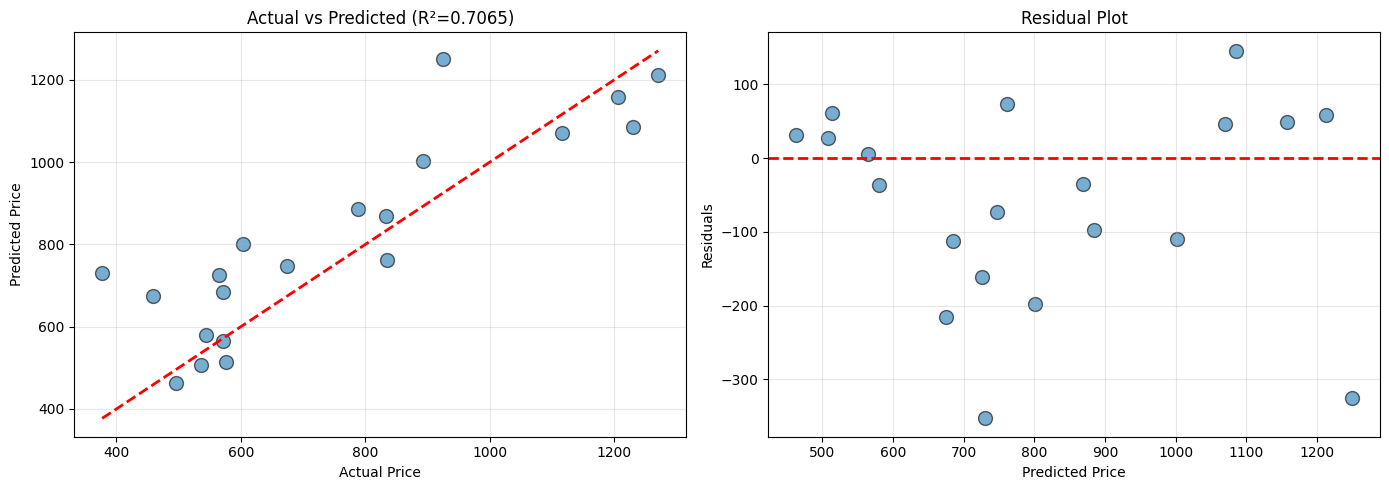

⚠️ Moderate fit: Some outliers visible in residual plot


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.6, s=100, edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs Predicted (R²={test_r2:.4f})')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.6, s=100, edgecolors='black')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("⚠️ Moderate fit: Some outliers visible in residual plot")

---
## 7. Feature Importance

Raw Coefficients (be careful with scale):
  Size                :     0.14
  Bedrooms            :    45.41
  Age                 :    -3.02
  Location_Quality    :    55.00

Standardized Coefficients (fair comparison):
            Feature  Standardized_Coef
0              Size           0.530375
1          Bedrooms           0.225580
3  Location_Quality           0.225112
2               Age          -0.157098


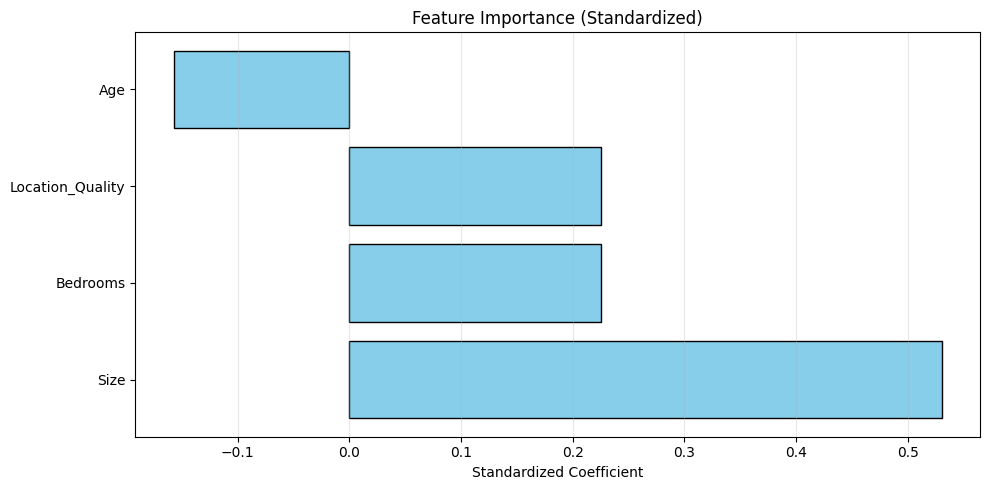

In [18]:
# Raw coefficients (affected by scale)
print("Raw Coefficients (be careful with scale):")
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat:20}: {coef:8.2f}")

# Standardized coefficients (fair comparison)
X_scaled = StandardScaler().fit_transform(X_train)
y_scaled = (y_train - y_train.mean()) / y_train.std()

model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y_scaled)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Standardized_Coef': model_scaled.coef_,
    'Abs_Coef': np.abs(model_scaled.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nStandardized Coefficients (fair comparison):")
print(importance_df[['Feature', 'Standardized_Coef']])

# Plot
plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Standardized_Coef'], color='skyblue', edgecolor='black')
plt.xlabel('Standardized Coefficient')
plt.title('Feature Importance (Standardized)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 8. Outlier Detection & Solutions

Outlier Detection:
  Number of outliers (|residual| > 2σ): 1 / 20
  Percentage: 5.0%


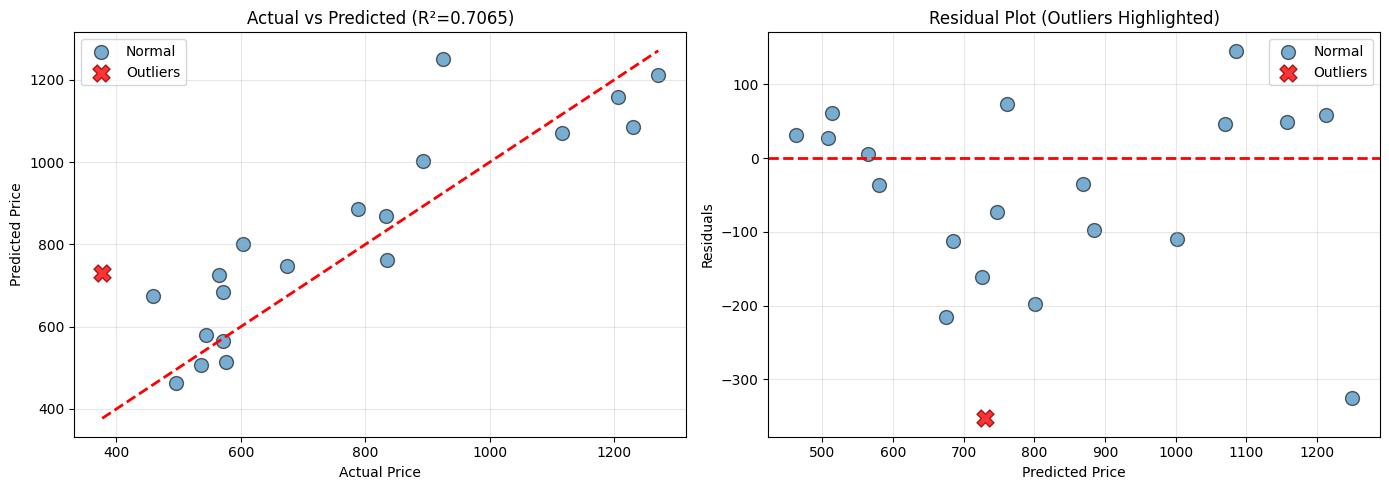


⚠️ Outliers pull the regression line (increase error)
✓ Solutions: Remove outliers, use robust regression, or try different models


In [20]:
# Identify and visualize outliers
from scipy import stats

# Calculate standardized residuals
standardized_residuals = (residuals - residuals.mean()) / residuals.std()

# Outliers: |standardized residual| > 2 (more than 2 std from mean)
outlier_mask = np.abs(standardized_residuals) > 2
outlier_count = outlier_mask.sum()

print("Outlier Detection:")
print(f"  Number of outliers (|residual| > 2σ): {outlier_count} / {len(y_test)}")
print(f"  Percentage: {outlier_count/len(y_test)*100:.1f}%")

# Plot with outliers highlighted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted (highlight outliers)
axes[0].scatter(y_test[~outlier_mask], y_pred_test[~outlier_mask], 
               alpha=0.6, s=100, edgecolors='black', label='Normal')
axes[0].scatter(y_test[outlier_mask], y_pred_test[outlier_mask], 
               alpha=0.8, s=150, color='red', edgecolors='darkred', marker='X', label='Outliers')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs Predicted (R²={test_r2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals (highlight outliers)
axes[1].scatter(y_pred_test[~outlier_mask], residuals[~outlier_mask], 
               alpha=0.6, s=100, edgecolors='black', label='Normal')
axes[1].scatter(y_pred_test[outlier_mask], residuals[outlier_mask], 
               alpha=0.8, s=150, color='red', edgecolors='darkred', marker='X', label='Outliers')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot (Outliers Highlighted)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n⚠️ Outliers pull the regression line (increase error)")
print(f"✓ Solutions: Remove outliers, use robust regression, or try different models")

In [21]:
# Option 1: Remove outliers and retrain
X_clean = X_test[~outlier_mask]
y_clean = y_test[~outlier_mask]

model_clean = LinearRegression()
model_clean.fit(X_train, y_train)
y_pred_clean = model_clean.predict(X_clean)

r2_clean = r2_score(y_clean, y_pred_clean)
rmse_clean = np.sqrt(mean_squared_error(y_clean, y_pred_clean))

print("Option 1: Remove Outliers from Test Set")
print(f"  Original R²:  {test_r2:.4f}")
print(f"  After removing outliers R²: {r2_clean:.4f}")
print(f"  RMSE: {rmse_clean:.2f}k (vs {test_rmse:.2f}k)")

print("\nOption 2: Use Robust Regression (see 04_support_vector_regression.ipynb)")
print("  SVR with epsilon tube is more robust to outliers")

print("\nOption 3: Try Tree-Based Models (see 05_decision_tree_regression.ipynb)")
print("  Decision Trees/Random Forest less sensitive to outliers")

print("\nOption 4: Add More Features")
print("  Missing important features → high residuals")
print("  Better features = better fit")

Option 1: Remove Outliers from Test Set
  Original R²:  0.7065
  After removing outliers R²: 0.7688
  RMSE: 125.55k (vs 145.60k)

Option 2: Use Robust Regression (see 04_support_vector_regression.ipynb)
  SVR with epsilon tube is more robust to outliers

Option 3: Try Tree-Based Models (see 05_decision_tree_regression.ipynb)
  Decision Trees/Random Forest less sensitive to outliers

Option 4: Add More Features
  Missing important features → high residuals
  Better features = better fit


---
## 9. Detect Multicollinearity

Feature Correlations:
                      Size  Bedrooms       Age  Location_Quality
Size              1.000000  0.066733  0.066015          0.073060
Bedrooms          0.066733  1.000000  0.050752         -0.070850
Age               0.066015  0.050752  1.000000         -0.182187
Location_Quality  0.073060 -0.070850 -0.182187          1.000000


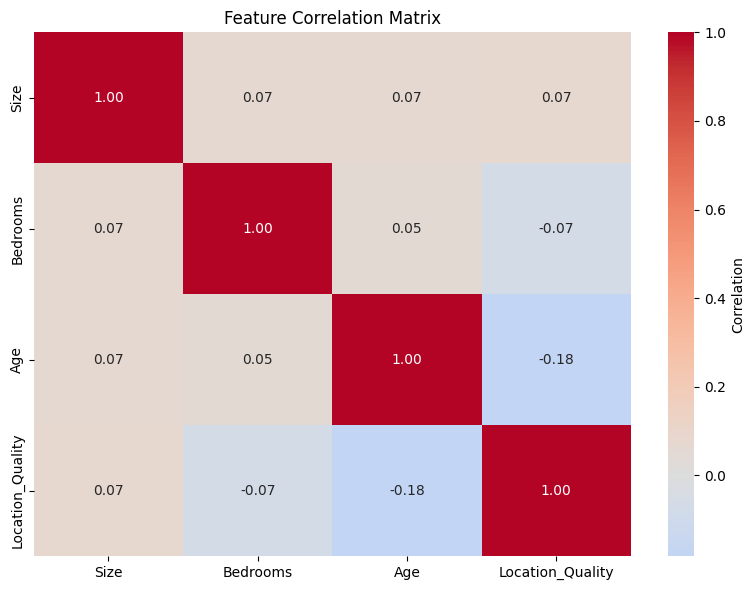


⚠️ Multicollinearity:
  High correlation (>0.7) between features = multicollinearity
  Problem: Model unstable, coefficients unreliable
  Solution: Remove one of correlated features or use regularization


In [22]:
# Correlation matrix
corr_matrix = X.corr()

print("Feature Correlations:")
print(corr_matrix)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\n⚠️ Multicollinearity:")
print("  High correlation (>0.7) between features = multicollinearity")
print("  Problem: Model unstable, coefficients unreliable")
print("  Solution: Remove one of correlated features or use regularization")

---
## Key Takeaways

1. **Multiple regression**: Many features → 1 prediction
2. **Equation**: y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ
3. **Check correlation**: Understand which features matter
4. **Standardize coefficients** for fair importance comparison
5. **Watch for multicollinearity**: Remove correlated features
6. **Compare train/test**: Detect overfitting

Much more powerful than simple regression!

---
## Your Turn

1. Load a dataset with 3+ features
2. Train multiple regression
3. Check feature importance
4. Look for multicollinearity
5. Evaluate R² and RMSE

In [ ]:
# Your code here